## Load in Datasets

In [28]:
from pathlib import Path
import pandas as pd

data_dir = Path("data")

# LFM-1b
listening = pd.read_csv(data_dir / "LFM-1b-Le75.csv", header=None, names=["user_id", "artist_id", "play_count"])
artist = pd.read_csv(data_dir / "LFM1b-MB-artists.txt", sep="\t", header=None, names=["artist_id", "artist_name", "gender_breakdown"])

# LastFM-360k
listening_360 = pd.read_csv(data_dir / "LastFM360k-Le75.txt")
listening_360.columns = ["user_id", "artist_id", "play_count"]
artist_360 = pd.read_csv(data_dir / "LastFM360k-MB-artists.txt", sep="\t", header=None, names=["artist_id", "artist_name", "gender_breakdown", "mb_id"])

In [22]:
print(listening.head())
print(listening.shape)

print(artist.head())
print(artist.shape)

print(listening_360.head())
print(listening_360.shape)

print(artist_360.head())
print(artist_360.shape)

   user_id  artist_id  play_count
0      384         18         3.0
1      384         30       153.0
2      384         43         7.0
3      384         47       518.0
4      384         48         5.0
(48323180, 3)
   artist_id     artist_name gender_breakdown
0          1        Megadeth       4/20/0/0/0
1          2       Lil Wayne        0/1/0/0/0
2          3    Foo Fighters        0/8/0/0/0
3          4  Porcupine Tree        0/6/0/0/0
4          5          No-Man        1/3/0/0/0
(3190371, 3)
   user_id  artist_id  play_count
0        0          0        2137
1        0          1        1099
2        0          2         897
3        0          3         717
4        0          4         706
(6541600, 3)
   artist_id         artist_name gender_breakdown  \
0     164618            genlevel        1/0/0/0/0   
1      77828  thelma blankenship        1/0/0/0/0   
2      14379    the damning well        0/4/0/0/0   
3      53216           andy dick        0/1/0/0/0   
4     10591

In [29]:
artist[["unknown", "male", "female", "other", "na"]] = artist["gender_breakdown"].str.split("/", expand=True).astype(int)

def classify_gender(row):
    if row["female"] > 0 and row["male"] == 0:
        return "female"
    elif row["male"] > 0 and row["female"] == 0:
        return "male"
    elif row["female"] > 0 and row["male"] > 0:
        return "mixed"
    else:
        return "unknown"

artist["gender"] = artist.apply(classify_gender, axis=1)
print(artist["gender"].value_counts())
print(artist["gender"].value_counts(normalize=True))

gender
unknown    2752394
male        342829
female       73171
mixed        21977
Name: count, dtype: int64
gender
unknown    0.862719
male       0.107457
female     0.022935
mixed      0.006889
Name: proportion, dtype: float64


In [31]:
# Merge listening with artist gender
listening_merged = listening.merge(artist[["artist_id", "gender"]], on="artist_id", how="left")

# Play counts by gender
print(listening_merged.groupby("gender")["play_count"].sum())
gender_plays = listening_merged.groupby("gender")["play_count"].sum()
print(gender_plays)
print(gender_plays / gender_plays.sum())

gender
female      66882926.0
male       506482873.0
mixed       84988804.0
unknown    209636846.0
Name: play_count, dtype: float64
gender
female      66882926.0
male       506482873.0
mixed       84988804.0
unknown    209636846.0
Name: play_count, dtype: float64
gender
female     0.077055
male       0.583511
mixed      0.097914
unknown    0.241519
Name: play_count, dtype: float64


In [32]:
# How many unique artists per gender?
print(listening_merged.groupby("gender")["artist_id"].nunique())

# Average plays per artist by gender
avg_plays = listening_merged.groupby("gender")["play_count"].mean()
print(avg_plays)

# Median plays per artist by gender (less skewed by superstars)
median_plays = listening_merged.groupby("gender")["play_count"].median()
print(median_plays)

gender
female      27438
male       128995
mixed        7267
unknown    421245
Name: artist_id, dtype: int64
gender
female     15.648551
male       20.289201
mixed      24.828668
unknown    13.384268
Name: play_count, dtype: float64
gender
female     2.0
male       3.0
mixed      3.0
unknown    2.0
Name: play_count, dtype: float64


In [33]:
# Top 20 most-played artists and their gender
top_artists = listening_merged.groupby(["artist_id", "gender"])["play_count"].sum().reset_index()
top_artists = top_artists.sort_values("play_count", ascending=False).head(20)
top_artists = top_artists.merge(artist[["artist_id", "artist_name"]], on="artist_id", how="left")
print(top_artists[["artist_name", "gender", "play_count"]])

              artist_name   gender  play_count
0               Radiohead     male   2583521.0
1             The Beatles     male   2470811.0
2              Pink Floyd     male   2094891.0
3               Daft Punk     male   2047174.0
4               Metallica     male   1894880.0
5             Linkin Park     male   1878695.0
6                    Muse     male   1831174.0
7                Coldplay     male   1775041.0
8          Arctic Monkeys     male   1702441.0
9   Red Hot Chili Peppers     male   1577816.0
10       System of a Down     male   1562373.0
11                Nirvana  unknown   1437409.0
12              Rammstein     male   1418713.0
13            Iron Maiden     male   1376072.0
14           Depeche Mode     male   1365434.0
15        Nine Inch Nails    mixed   1248794.0
16           Lana Del Rey   female   1220124.0
17              In Flames     male   1213079.0
18                 The xx    mixed   1177259.0
19                Placebo     male   1176615.0


In [34]:
# Gender distribution in top 100, 500, 1000 most-played artists
top_all = listening_merged.groupby(["artist_id", "gender"])["play_count"].sum().reset_index()
top_all = top_all.sort_values("play_count", ascending=False)

for n in [100, 500, 1000]:
    top_n = top_all.head(n)
    print(f"\nTop {n} artists by gender:")
    print(top_n["gender"].value_counts(normalize=True))


Top 100 artists by gender:
gender
male       0.68
mixed      0.18
unknown    0.10
female     0.04
Name: proportion, dtype: float64

Top 500 artists by gender:
gender
male       0.698
mixed      0.152
unknown    0.088
female     0.062
Name: proportion, dtype: float64

Top 1000 artists by gender:
gender
male       0.665
mixed      0.146
unknown    0.120
female     0.069
Name: proportion, dtype: float64


count    79676.000000
mean         0.105878
std          0.123889
min          0.000000
25%          0.023247
50%          0.064942
75%          0.142713
max          1.000000
Name: female_pct, dtype: float64


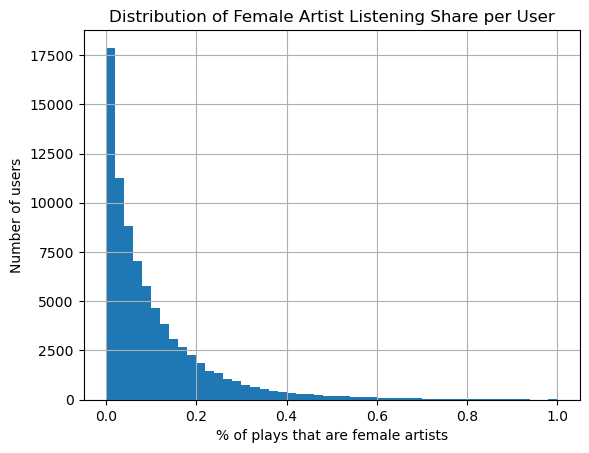

In [ ]:
# Per-user gender listening profile
user_gender = listening_merged[listening_merged["gender"] != "unknown"].groupby(["user_id", "gender"])["play_count"].sum().unstack(fill_value=0)
user_gender["total"] = user_gender.sum(axis=1)
user_gender["female_pct"] = user_gender["female"] / user_gender["total"]

print(user_gender["female_pct"].describe())

# Distribution of female listening percentage
import matplotlib.pyplot as plt

user_gender["female_pct"].hist(bins=50)
plt.xlabel("% of plays that are female artists")
plt.ylabel("Number of users")
plt.title("Distribution of Female Artist Listening Share per User")
plt.show()

Users: 79678, Artists: 584945, Interactions: 48323180
Sparsity: 0.998963


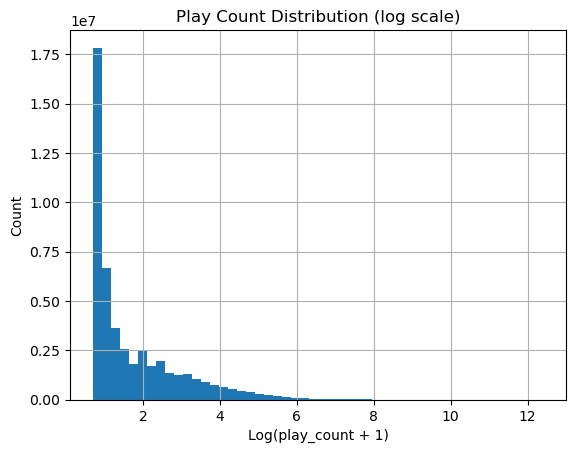

count    79678.000000
mean       606.480835
std        707.483078
min          3.000000
25%        175.000000
50%        384.000000
75%        786.000000
max      29151.000000
Name: artist_id, dtype: float64
count    584945.000000
mean         82.611493
std         515.629063
min           1.000000
25%           6.000000
50%          11.000000
75%          30.000000
max       32014.000000
Name: user_id, dtype: float64


In [ ]:
# 1. Data sparsity — crucial for algorithm selection
n_users = listening["user_id"].nunique()
n_artists = listening["artist_id"].nunique()
n_interactions = len(listening)
sparsity = 1 - (n_interactions / (n_users * n_artists))
print(f"Users: {n_users}, Artists: {n_artists}, Interactions: {n_interactions}")
print(f"Sparsity: {sparsity:.6f}")

# 2. Play count distribution (log scale makes sense here)
import numpy as np
listening["play_count"].apply(np.log1p).hist(bins=50)
plt.xlabel("Log(play_count + 1)")
plt.ylabel("Count")
plt.title("Play Count Distribution (log scale)")
plt.show()

# 3. Artists per user / users per artist
print(listening.groupby("user_id")["artist_id"].nunique().describe())
print(listening.groupby("artist_id")["user_id"].nunique().describe())

In [37]:
# Users per artist by gender
artist_popularity = listening_merged.groupby(["artist_id", "gender"])["user_id"].nunique().reset_index()
artist_popularity.columns = ["artist_id", "gender", "n_users"]

print(artist_popularity.groupby("gender")["n_users"].describe())

            count        mean          std  min  25%   50%    75%      max
gender                                                                    
female    27438.0  155.771740   732.540016  1.0  7.0  17.0   63.0  23695.0
male     128995.0  193.520485   878.850193  1.0  8.0  19.0   77.0  32014.0
mixed      7267.0  471.034953  1594.246115  1.0  9.0  32.0  204.0  24952.0
unknown  421245.0   37.182469   212.372886  1.0  6.0  10.0   22.0  29034.0


In [40]:
def check_artist(name):
    match = artist[artist["artist_name"].str.contains(name, case=False, na=False)][["artist_name", "gender_breakdown", "gender"]].head(3)
    print(match)
    print()

# Known male
check_artist("Ed Sheeran")
check_artist("Metallica")

# Known female
check_artist("Taylor Swift")
check_artist("Beyoncé")
check_artist("Lana Del Rey")

# Known mixed
check_artist("Fleetwood Mac")
check_artist("Paramore")

                      artist_name gender_breakdown   gender
4037                   Ed Sheeran        0/1/0/0/0     male
41632  Foy Vance feat. Ed Sheeran        0/1/0/0/0     male
64444      Ed Sheeran & Passenger        2/0/0/0/0  unknown

                             artist_name gender_breakdown   gender
54                             Metallica        0/8/0/0/0     male
6791   METALLICA (Four Horsemen Tribute)        1/0/0/0/0  unknown
48824             Metallica - I Disapear        1/0/0/0/0  unknown

                       artist_name gender_breakdown   gender
3743                  Taylor Swift        0/0/1/0/0   female
82541        Taylor Swift ft Usher        1/0/0/0/0  unknown
106652  Taylor Swift & Def Leppard        0/7/0/0/0     male

               artist_name gender_breakdown   gender
2987               Beyoncé        0/0/1/0/0   female
15838  Jay-Z feat. Beyoncé        0/1/0/0/0     male
27606    Beyoncé/Ghostface        1/0/0/0/0  unknown

                       artist_na